In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("HealthCare Analytics For Doctor Visits.csv")
print('Data Loaded!')
df.head()

Data Loaded!


,Unnamed: 0,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
0,1,1,female,0.19,0.55,1,4,1,yes,no,no,no,no
1,2,1,female,0.19,0.45,1,2,1,yes,no,no,no,no
2,3,1,male,0.19,0.90,3,0,0,no,no,no,no,no
3,4,1,male,0.19,0.15,1,0,0,no,no,no,no,no
4,5,1,male,0.19,0.45,2,5,1,no,no,no,yes,no


In [6]:
df.tail()

,Unnamed: 0,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
5185,5186,0,female,0.22,0.55,0,0,0,no,no,no,no,no
5186,5187,0,male,0.27,1.30,0,0,1,no,no,no,no,no
5187,5188,0,female,0.37,0.25,1,0,1,no,no,yes,no,no
5188,5189,0,female,0.52,0.65,0,0,0,no,no,no,no,no
5189,5190,0,male,0.72,0.25,0,0,0,no,no,yes,no,no


In [7]:
df.shape

(5190, 13)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5190 entries, 0 to 5189
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  5190 non-null   int64  
 1   visits      5190 non-null   int64  
 2   gender      5190 non-null   object 
 3   age         5190 non-null   float64
 4   income      5190 non-null   float64
 5   illness     5190 non-null   int64  
 6   reduced     5190 non-null   int64  
 7   health      5190 non-null   int64  
 8   private     5190 non-null   object 
 9   freepoor    5190 non-null   object 
 10  freerepat   5190 non-null   object 
 11  nchronic    5190 non-null   object 
 12  lchronic    5190 non-null   object 
dtypes: float64(2), int64(5), object(6)
memory usage: 527.2+ KB


In [9]:
df.describe()

,Unnamed: 0,visits,age,income,illness,reduced,health
count,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000
mean,2595.500000,0.301734,0.406385,0.583160,1.431985,0.861850,1.217534
std,1498.368279,0.798134,0.204782,0.368907,1.384152,2.887628,2.124266
min,1.000000,0.000000,0.190000,0.000000,0.000000,0.000000,0.000000
25%,1298.250000,0.000000,0.220000,0.250000,0.000000,0.000000,0.000000
50%,2595.500000,0.000000,0.320000,0.550000,1.000000,0.000000,0.000000
75%,3892.750000,0.000000,0.620000,0.900000,2.000000,0.000000,2.000000
max,5190.000000,9.000000,0.720000,1.500000,5.000000,14.000000,12.000000


In [10]:
df.isnull().sum()

Unnamed: 0    0
visits        0
gender        0
age           0
income        0
illness       0
reduced       0
health        0
private       0
freepoor      0
freerepat     0
nchronic      0
lchronic      0
dtype: int64

Find out the total number of people based on their count of illness

In [11]:
df['illness'].value_counts()

illness
1    1638
0    1554
2     946
3     542
4     274
5     236
Name: count, dtype: int64

In [12]:
df['gender'].value_counts()

gender
female    2702
male      2488
Name: count, dtype: int64

Visualize and analyse the maximum, minimum and medium income


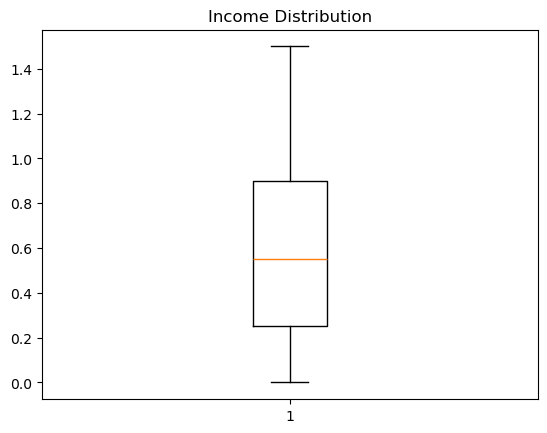

In [13]:
y = list(df.income)
plt.boxplot(y)
plt.title('Income Distribution')
plt.show()

Visualize if there are any missing values in the dataset based on a heatmap

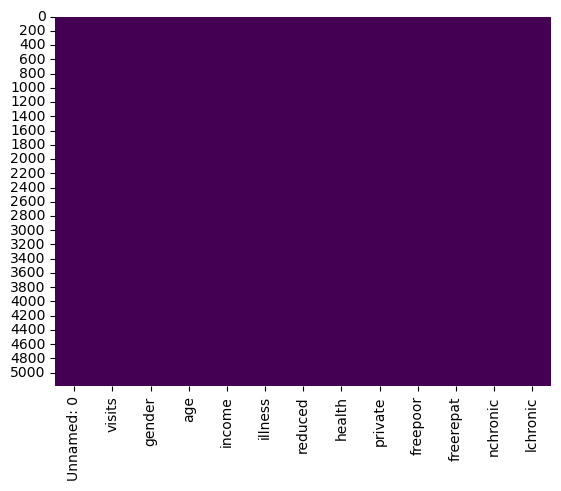

In [18]:
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.show()

Find out the correlation between variables in the given dataset

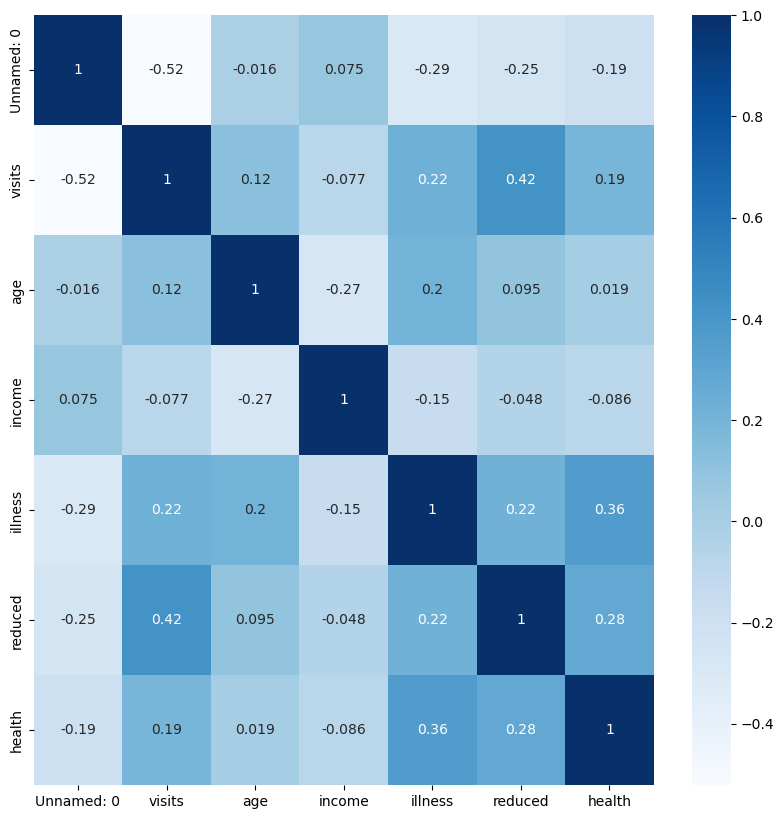

In [20]:
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(numeric_only=True), cbar=True, annot=True, cmap='Blues')
plt.show()

Analyse how the income of a patient affects the number of visits to the hospital

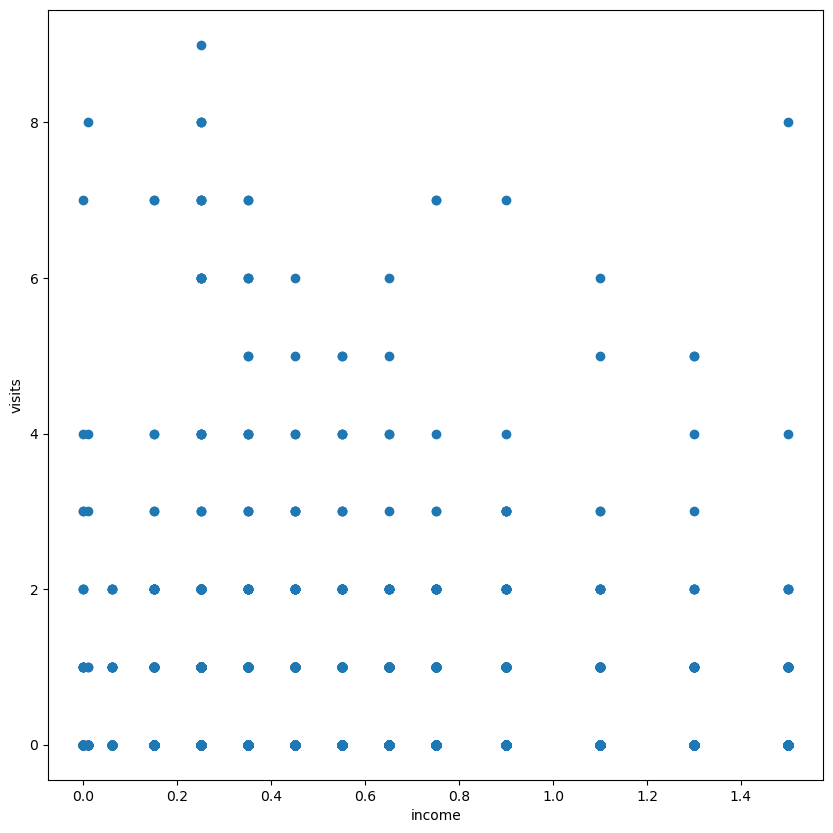

In [22]:
plt.figure(figsize=(10,10))
plt.scatter(x='income', y='visits', data=df)
plt.xlabel('income')
plt.ylabel('visits')
plt.show()

Count and visualize the number of males and females affected by illness.


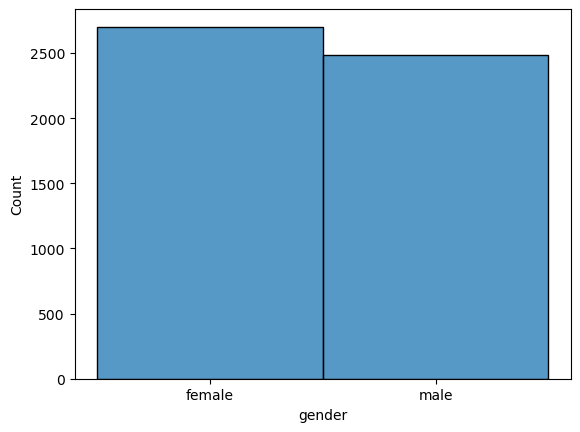

In [23]:
sns.histplot(df.gender, bins=2)
plt.show()

Visualize the percentage of people getting govt health insurance

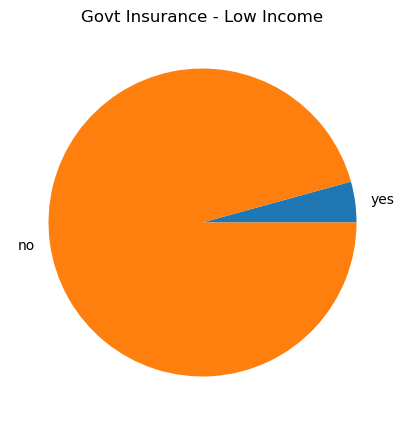

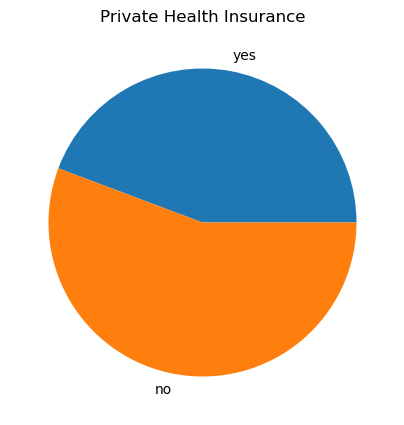

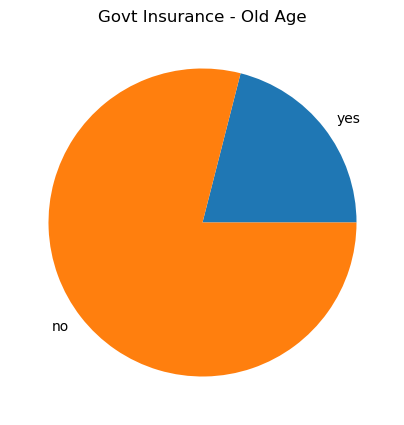

In [24]:
label = ['yes','no']

Y = df[df['freepoor']=='yes']
N = df[df['freepoor']=='no']
x = [Y.shape[0], N.shape[0]]
plt.figure(figsize=(5,5))
plt.pie(x, labels=label)
plt.title('Govt Insurance - Low Income')
plt.show()

Y = df[df['private']=='yes']
N = df[df['private']=='no']
x = [Y.shape[0], N.shape[0]]
plt.figure(figsize=(5,5))
plt.pie(x, labels=label)
plt.title('Private Health Insurance')
plt.show()

Y = df[df['freerepat']=='yes']
N = df[df['freerepat']=='no']
x = [Y.shape[0], N.shape[0]]
plt.figure(figsize=(5,5))
plt.pie(x, labels=label)
plt.title('Govt Insurance - Old Age')
plt.show()

Plot a horizontal bar chart to analyze reduced activity days based on Gender

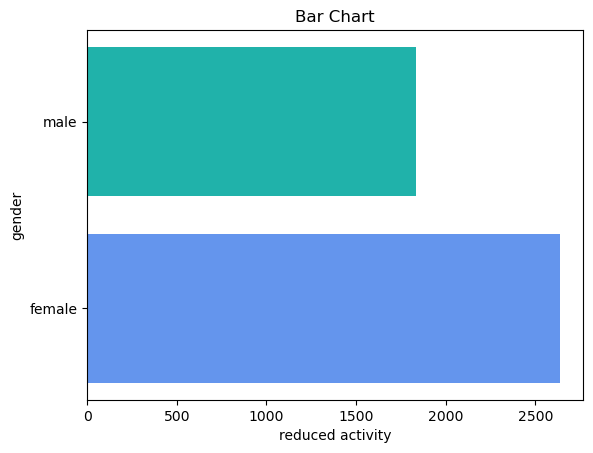

In [25]:
db = df.groupby('gender')['reduced'].sum().to_frame().reset_index()
plt.barh(db['gender'], db['reduced'], color=['cornflowerblue','lightseagreen'])
plt.title('Bar Chart')
plt.xlabel('reduced activity')
plt.ylabel('gender')
plt.show()

# Problem Statement 1
How does a patient's illness and chronic condition affect the number of doctor visits?

illness
0    1554
1    1638
2     946
3     542
4     274
5     236
Name: count, dtype: int64


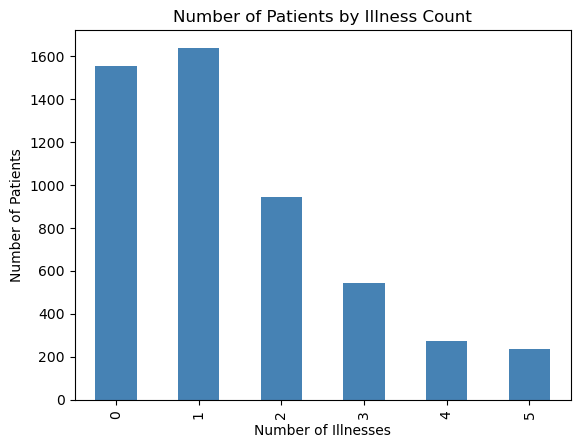

In [26]:
illness_count = df['illness'].value_counts().sort_index()
print(illness_count)

illness_count.plot(kind='bar', color='steelblue')
plt.title('Number of Patients by Illness Count')
plt.xlabel('Number of Illnesses')
plt.ylabel('Number of Patients')
plt.show()

From above analysis:
- Patients with 1 illness are highest in count (1638)
- Patients with 0 illness are second (1554)
- As illness count increases, patient count decreases

Reason: Most people visit doctor for a single minor illness.
Patients with multiple illnesses are fewer because they may
already be on long-term treatment plans.

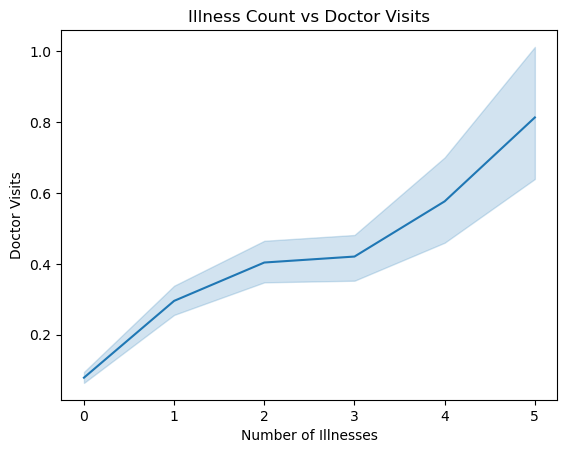

In [27]:
sns.lineplot(x='illness', y='visits', data=df)
plt.title('Illness Count vs Doctor Visits')
plt.xlabel('Number of Illnesses')
plt.ylabel('Doctor Visits')
plt.show()

In [28]:
print('Non-chronic vs Chronic patient visits:')
print(df.groupby('nchronic')['visits'].mean())
print('\nLong term chronic patient visits:')
print(df.groupby('lchronic')['visits'].mean())

Non-chronic vs Chronic patient visits:
nchronic
no     0.272111
yes    0.345602
Name: visits, dtype: float64

Long term chronic patient visits:
lchronic
no     0.261941
yes    0.603306
Name: visits, dtype: float64


# Problem Statement 2
How does income and insurance type influence a patient's access to healthcare?

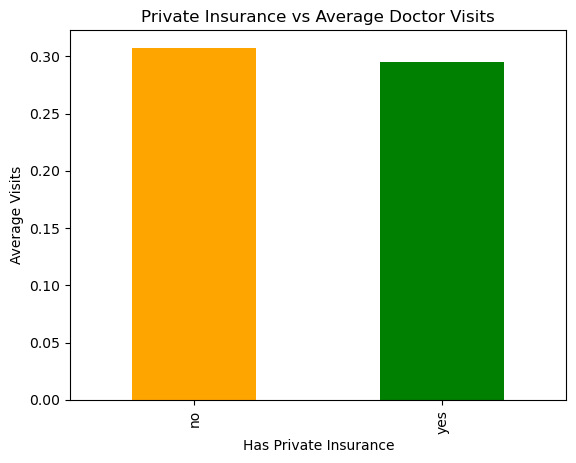

In [29]:
df.groupby('private')['visits'].mean().plot(
    kind='bar', color=['orange','green'])
plt.title('Private Insurance vs Average Doctor Visits')
plt.xlabel('Has Private Insurance')
plt.ylabel('Average Visits')
plt.show()

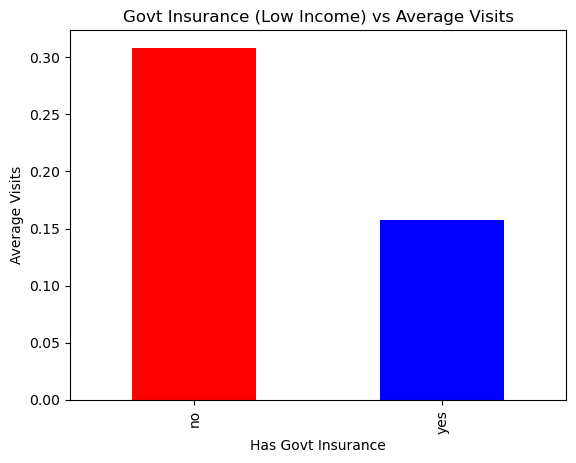

In [30]:
df.groupby('freepoor')['visits'].mean().plot(
    kind='bar', color=['red','blue'])
plt.title('Govt Insurance (Low Income) vs Average Visits')
plt.xlabel('Has Govt Insurance')
plt.ylabel('Average Visits')
plt.show()

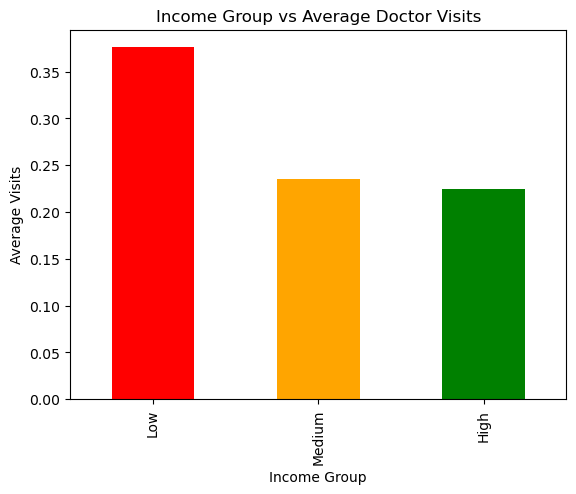

In [31]:
df['income_group'] = pd.cut(df['income'], bins=3,
                    labels=['Low','Medium','High'])
df.groupby('income_group', observed=True)['visits'].mean().plot(
    kind='bar', color=['red','orange','green'])
plt.title('Income Group vs Average Doctor Visits')
plt.xlabel('Income Group')
plt.ylabel('Average Visits')
plt.show()

# Problem Statement 3
How do gender and reduced activity days relate to the frequency of doctor visits?

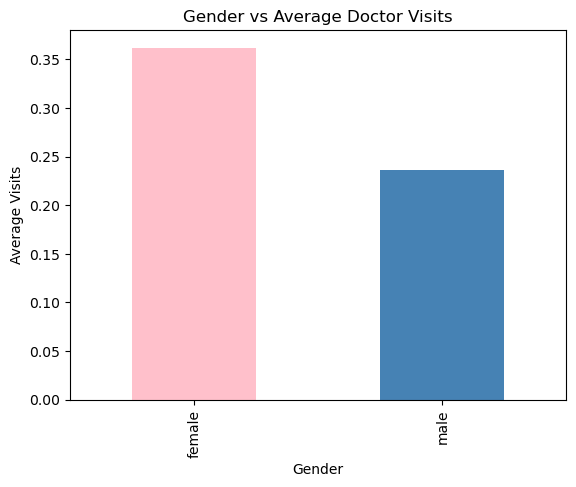

Average visits by gender:
gender
female    0.361954
male      0.236334
Name: visits, dtype: float64


In [32]:
df.groupby('gender')['visits'].mean().plot(
    kind='bar', color=['pink','steelblue'])
plt.title('Gender vs Average Doctor Visits')
plt.xlabel('Gender')
plt.ylabel('Average Visits')
plt.show()

print('Average visits by gender:')
print(df.groupby('gender')['visits'].mean())

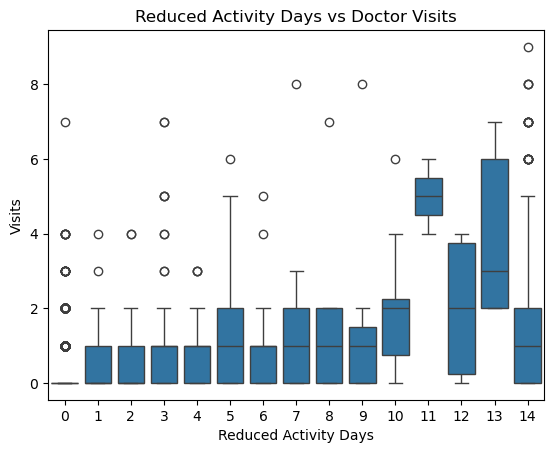

In [33]:
sns.boxplot(x='reduced', y='visits', data=df)
plt.title('Reduced Activity Days vs Doctor Visits')
plt.xlabel('Reduced Activity Days')
plt.ylabel('Visits')
plt.show()

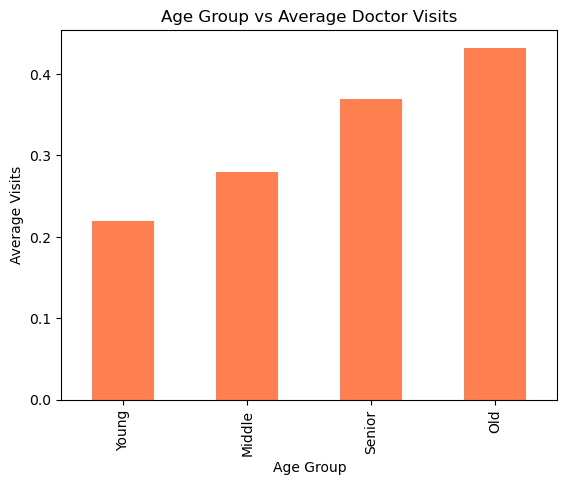

In [34]:
df['age_group'] = pd.cut(df['age'], bins=4,
                  labels=['Young','Middle','Senior','Old'])
df.groupby('age_group', observed=True)['visits'].mean().plot(
    kind='bar', color='coral')
plt.title('Age Group vs Average Doctor Visits')
plt.xlabel('Age Group')
plt.ylabel('Average Visits')
plt.show()

## Overall Conclusion

PS1: Patients with 1 illness visit the doctor most. 
Chronic patients visit significantly more than non-chronic.

PS2: Low income patients with govt insurance visit more. 
Private insurance holders also visit more due to easier access.

PS3: Females visit the doctor slightly more than males. 
More reduced activity days = more doctor visits.